#### Assignment no.09


#### Name: Wagh Purva Ramesh
#### Roll No:EN23107132
#### Batch:B

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [69]:
df1=pd.read_csv("winequality-red.csv",sep=";")

In [71]:
df2=pd.read_csv("winequality-white.csv",sep=";")

In [73]:
print(df1.columns)
print(df2.columns)


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [75]:
df = pd.concat([df1, df2], axis=0, ignore_index=True)


In [77]:
print(df.columns)


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [79]:
class_counts = df['quality'].value_counts()
print(class_counts)


quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [83]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [85]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [87]:
x=df.drop('quality',axis=1)

In [89]:
y=df['quality']

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)


In [93]:
from scipy.cluster import hierarchy


In [95]:
from sklearn.cluster import AgglomerativeClustering

In [97]:

hc_single = AgglomerativeClustering(
    n_clusters=3,
    linkage='single'
)

In [99]:
clusters_single = hc_single.fit_predict(X_scaled)


In [101]:
hc_complete = AgglomerativeClustering(
    n_clusters=3,
    linkage='complete'
)

clusters_complete = hc_complete.fit_predict(X_scaled)


In [102]:
df['cluster_single'] = clusters_single
df['cluster_complete'] = clusters_complete

In [103]:
print(pd.crosstab(df['quality'], df['cluster_single']))
print(pd.crosstab(df['quality'], df['cluster_complete']))


cluster_single     0  1  2
quality                   
3                 29  0  1
4                216  0  0
5               2138  0  0
6               2835  1  0
7               1079  0  0
8                193  0  0
9                  5  0  0
cluster_complete     0  1   2
quality                      
3                   30  0   0
4                  215  0   1
5                 2122  0  16
6                 2829  1   6
7                 1078  0   1
8                  193  0   0
9                    5  0   0


In [104]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [109]:
linked_single = linkage(X_scaled, method='single')


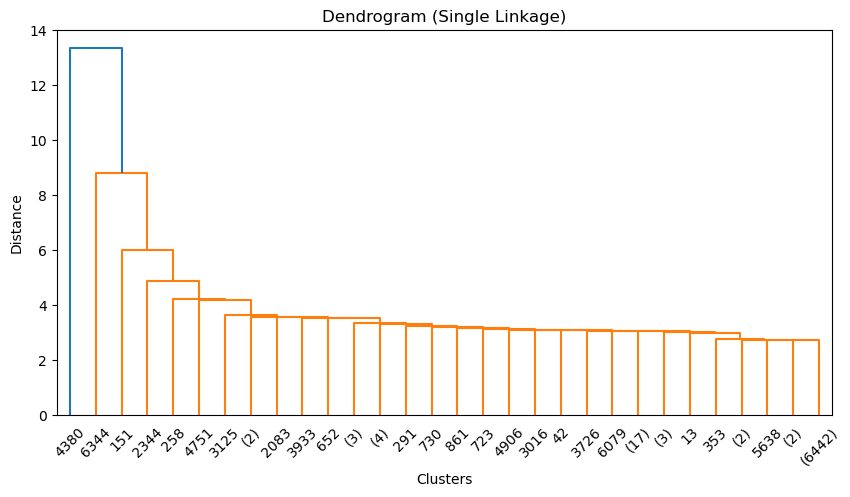

In [110]:
plt.figure(figsize=(10, 5))
dendrogram(linked_single, truncate_mode='lastp', p=30)
plt.title("Dendrogram (Single Linkage)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


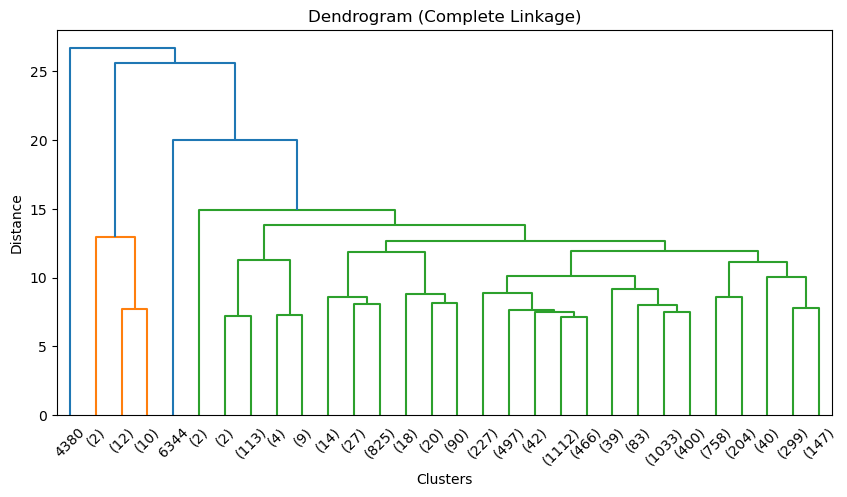

In [111]:
linked_complete = linkage(X_scaled, method='complete')

plt.figure(figsize=(10, 5))
dendrogram(linked_complete, truncate_mode='lastp', p=30)
plt.title("Dendrogram (Complete Linkage)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


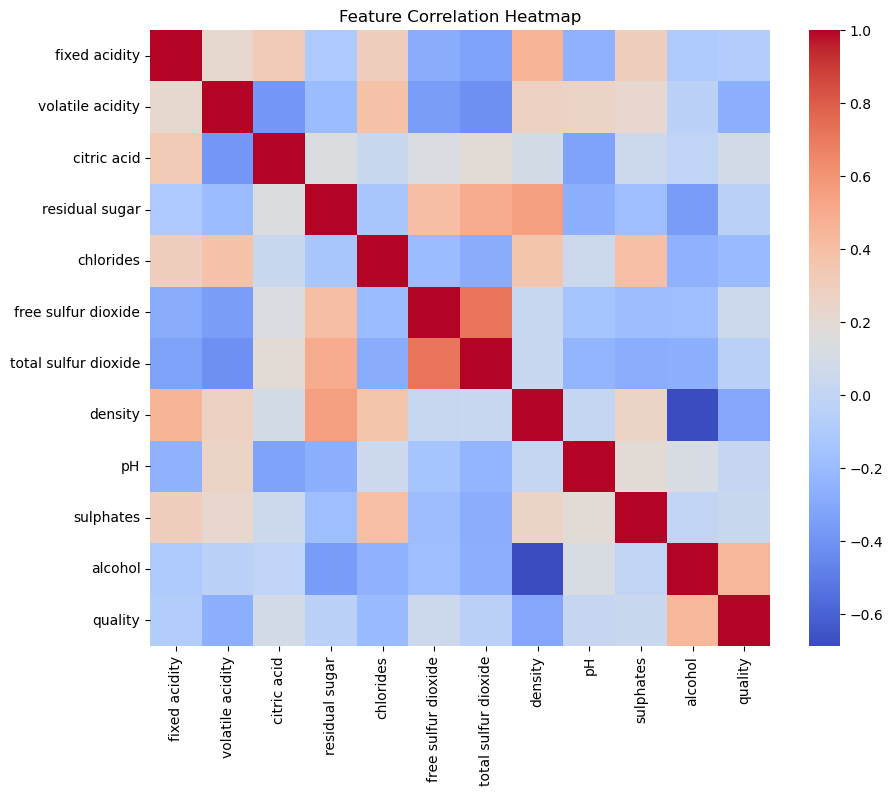

In [113]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(['cluster_single','cluster_complete'], axis=1)
            .corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
